In [6]:
# --- Setup: all imports in one place ---
import glob
import json
import importlib.util
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

In [11]:
from pathlib import Path
RECORDINGS_DIR = Path("recordings-download/*/")
RECORDINGS_BASE = Path("recordings-download/")

score_r1 = "oth_score_poc20260727.json"
score_r3 = "oth_score_pbg20260726.json"
score_r2 = "oth_score_pb220260706.json"
conversations = "conversation_poc20260727.jsonl"
post_survey_1 = "post_survey_poc20260727.json"
post_survey_2 = "post_survey_pbg20260726.json"

In [12]:
# Participants who had both r1 and r2
all_r1 = glob.glob(str(RECORDINGS_DIR / score_r1))
all_r1 = [x.split("/")[-2] for x in all_r1]
all_r2 = glob.glob(str(RECORDINGS_DIR / score_r2))
all_r2 = [x.split("/")[-2] for x in all_r2]

all_candidates = set(all_r1).intersection(set(all_r2))
all_candidates

{'p150', 'p329'}

In [13]:
len(all_candidates)

2

# Score Differences

In [14]:
# Mean / median / std for a field, across a set of participants.
# nasa_tlx=True reads post_survey["nasa_tlx"][field] instead of a top-level field.
import os
def report_avg(fn, kn, cands=all_candidates, nasa_tlx=False):
    vals = []
    for pid in cands:
        d = json.load(open(RECORDINGS_BASE / pid / fn))
        if not os.path.exists(RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"):
            continue
        try:
            vals.append(d["nasa_tlx"][kn] if nasa_tlx else int(d[kn]))
        except ValueError:
            vals.append(0)
    return np.mean(vals), np.median(vals), np.std(vals)

# Round-level score summary across all completers
print(f"{'round':>10} {'metric':>14} {'mean':>6} {'median':>7} {'std':>6}")
for rlabel, fn, kn in [("R1 (AI)", score_r1, "final_margin"), ("R2 (no AI)", score_r2, "final_margin"), ("R3 (no AI)", score_r3, "final_margin")]:
    m, md, sd = report_avg(fn, kn)
    print(f"{rlabel:>10} SCORE {m:>6.2f} {md:>7.1f} {sd:>6.2f}")

     round         metric   mean  median    std
   R1 (AI) SCORE -18.00   -18.0   0.00
R2 (no AI) SCORE  -2.00    -2.0   0.00
R3 (no AI) SCORE   4.00     4.0   0.00


# Separate Optimal Moves >= 2 vs. The Rest

In [35]:
# Merged 2-group split: won = score >= 2 (former win + won), lost = the rest.
good_pid, bad_pid = [], []
win_pid = []   # merged into won; kept empty so any legacy references still work
for pid in all_candidates:
    curr_f_r2 = json.load(open(RECORDINGS_BASE / pid / score_r2))
    curr_f_r3 = json.load(open(RECORDINGS_BASE / pid / score_r3))
    if not os.path.exists(RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"):
        continue
    if curr_f_r2["score"] + curr_f_r3["score"] >= 4:
        good_pid.append(pid)
    else:
        bad_pid.append(pid)

In [36]:
len(good_pid), len(bad_pid)

(2, 0)

# Demographic Differences

In [17]:
report_avg("demographics.json", "skill_rating", cands=good_pid + win_pid)

(np.float64(1.5), np.float64(1.5), np.float64(0.5))

In [18]:
report_avg("demographics.json", "skill_rating", cands=bad_pid)

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid val

(np.float64(nan), np.float64(nan), np.float64(nan))

In [19]:
report_avg("demographics.json", "age", cands=good_pid + win_pid)

(np.float64(46.5), np.float64(46.5), np.float64(2.5))

In [20]:
report_avg("demographics.json", "age", cands=bad_pid)

(np.float64(nan), np.float64(nan), np.float64(nan))

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


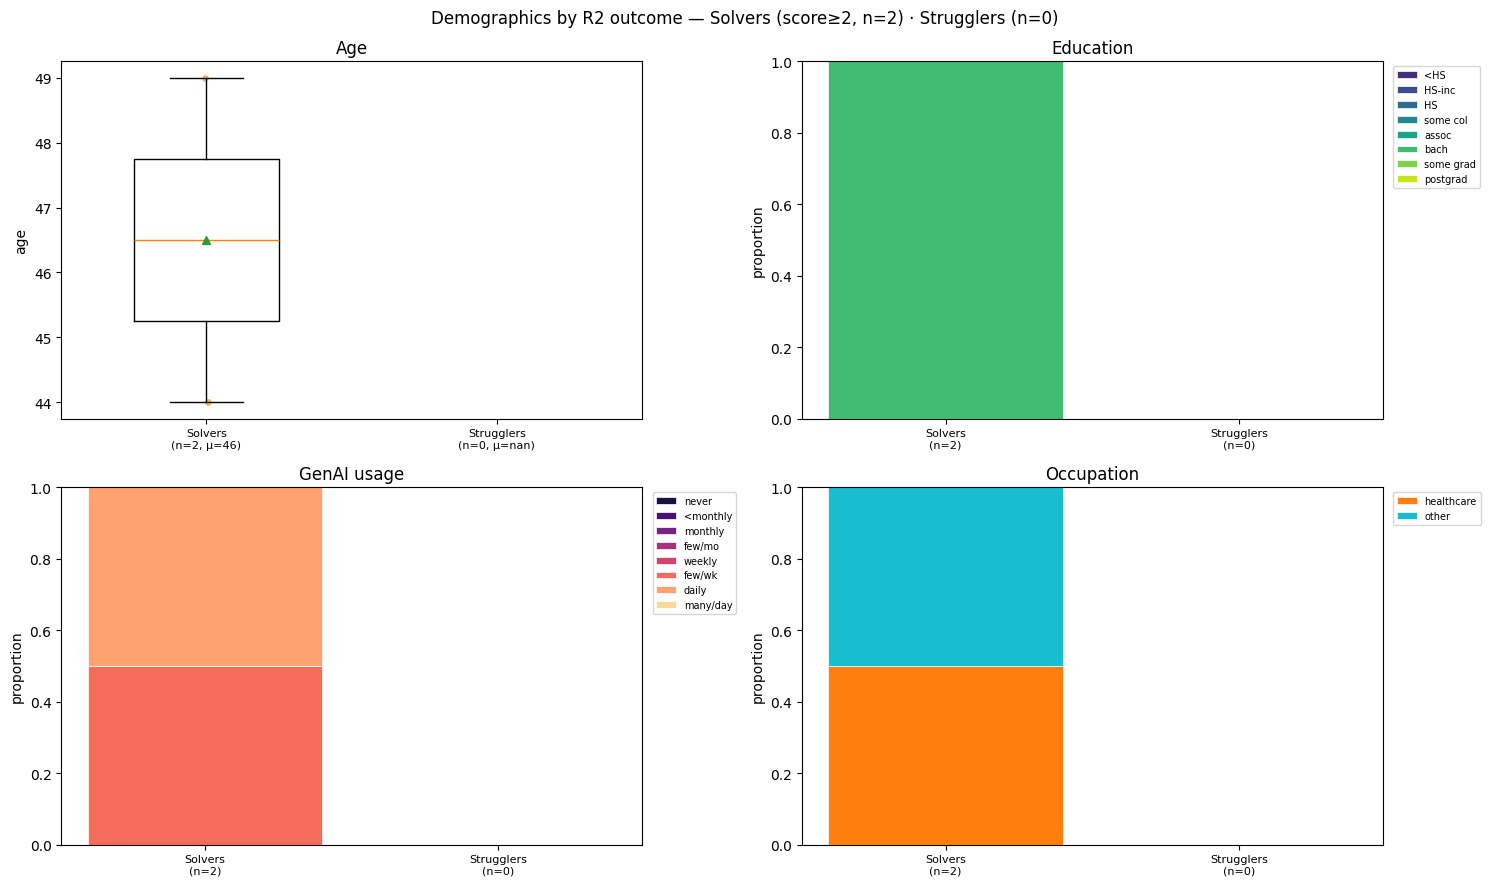

In [21]:
# --- Demographics: good_pid vs win_pid vs bad_pid ---
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

def load_demo(cands):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in cands if (RECORDINGS_BASE / pid / "demographics.json").exists()]

dg, dw, db = load_demo(good_pid), load_demo(win_pid), load_demo(bad_pid)
GROUPS = [("Solvers", dg, "#f59e0b"), ("Strugglers", db, "#ef4444")]

# Ordered categories (app option order) + short labels
EDU = (["less_than_hs","hs_incomplete","hs_graduate","some_college","associate","bachelors","some_postgrad","postgrad"],
       ["<HS","HS-inc","HS","some col","assoc","bach","some grad","postgrad"])
GEN = (["never","less_than_monthly","about_monthly","few_times_month","weekly","few_times_week","daily","several_times_day"],
       ["never","<monthly","monthly","few/mo","weekly","few/wk","daily","many/day"])

def props(demos, key, order):
    n = sum(1 for d in demos if d.get(key) in order) or 1
    c = Counter(d.get(key) for d in demos)
    return np.array([c.get(o, 0) / n for o in order])

def stacked(a, key, order, short, title, cmap="viridis"):
    x = np.arange(len(GROUPS))
    P = np.array([props(d, key, order) for _, d, _ in GROUPS])   # (3 groups, n_cats)
    colors = plt.get_cmap(cmap)(np.linspace(0.12, 0.92, len(order)))
    bottoms = np.zeros(len(GROUPS))
    for ci, lab in enumerate(short):
        a.bar(x, P[:, ci], bottom=bottoms, color=colors[ci], label=lab, edgecolor="white", lw=0.5)
        bottoms += P[:, ci]
    a.set_xticks(x); a.set_xticklabels([f"{nm}\n(n={len(d)})" for nm, d, _ in GROUPS], fontsize=8)
    a.set_ylim(0, 1); a.set_ylabel("proportion"); a.set_title(title)
    a.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=7)

fig, ax = plt.subplots(2, 2, figsize=(15, 9))

# Age — box + jittered points per group
ages = [[d["age"] for d in demos if d.get("age")] for _, demos, _ in GROUPS]
ax[0,0].boxplot(ages, positions=range(len(GROUPS)), widths=0.5, showmeans=True)
rng = np.random.default_rng(0)
for i, ((nm, _, col), v) in enumerate(zip(GROUPS, ages)):
    ax[0,0].scatter(rng.normal(i, 0.05, len(v)), v, s=16, alpha=0.6, color=col)
ax[0,0].set_xticks(range(len(GROUPS)))
ax[0,0].set_xticklabels([f"{nm}\n(n={len(v)}, μ={np.mean(v):.0f})" for (nm,_,_), v in zip(GROUPS, ages)], fontsize=8)
ax[0,0].set_ylabel("age"); ax[0,0].set_title("Age")

stacked(ax[0,1], "education", *EDU, "Education", cmap="viridis")
stacked(ax[1,0], "genai_usage", *GEN, "GenAI usage", cmap="magma")
occ = sorted({d.get("occupation") for _, dm, _ in GROUPS for d in dm if d.get("occupation")})
stacked(ax[1,1], "occupation", occ, occ, "Occupation", cmap="tab20")

fig.suptitle("Demographics by R2 outcome — Solvers (score≥2, n=%d) · Strugglers (n=%d)"
             % (len(dg), len(db)), fontsize=12)
plt.tight_layout(); plt.show()

# NASA-TLX Differences

/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid val

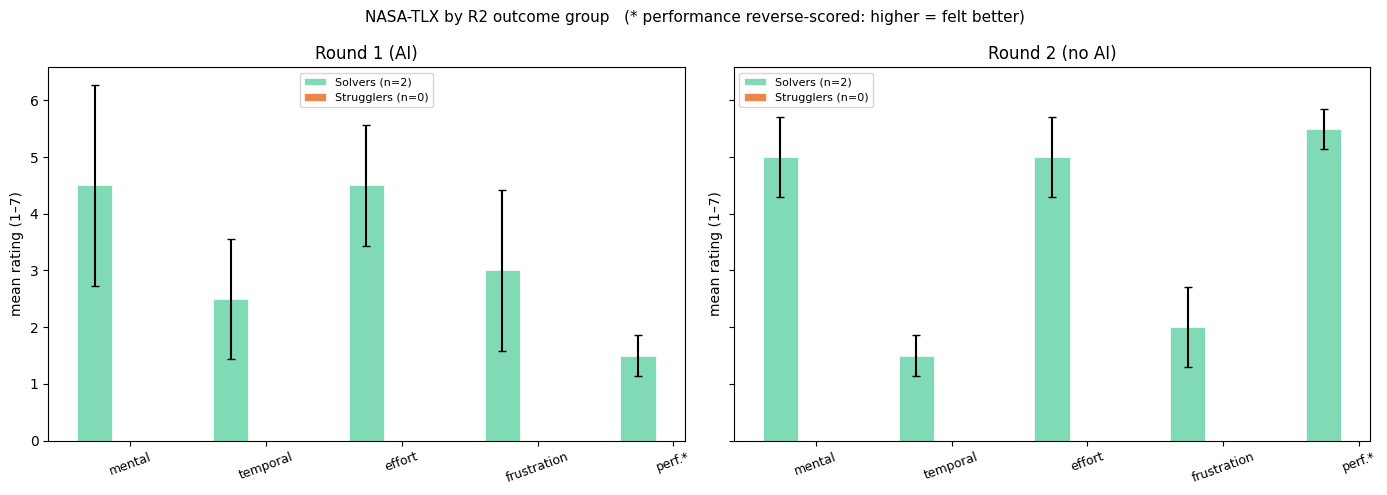

In [22]:
# --- NASA-TLX by R2 outcome group (Solvers / Strugglers), per round ---
# physical_demand was dropped from the instrument (present in only some batch-1
# files), so we compare the 5 current items. performance is reverse-scored:
# a HIGHER rating means the participant felt they did BETTER (lower workload).
TLX_ITEMS = ["mental_demand", "temporal_demand", "effort", "frustration", "performance"]
TLX_SHORT = ["mental", "temporal", "effort", "frustration", "perf.*"]
GROUPST = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
ROUNDS = [("Round 1 (AI)", post_survey_1), ("Round 2 (no AI)", post_survey_2)]

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
x = np.arange(len(TLX_ITEMS)); w = 0.26
for a, (rlabel, sfile) in zip(ax, ROUNDS):
    for gi, (nm, pids_, col) in enumerate(GROUPST):
        s = [report_avg(sfile, it, cands=pids_, nasa_tlx=True) for it in TLX_ITEMS]
        means = [v[0] for v in s]
        sems = [v[2] / np.sqrt(len(pids_)) for v in s]      # std error of the mean
        a.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
              label=f"{nm} (n={len(pids_)})", edgecolor="white", lw=0.5)
    a.set_xticks(x); a.set_xticklabels(TLX_SHORT, rotation=20, fontsize=9)
    a.set_title(rlabel); a.set_ylabel("mean rating (1–7)"); a.legend(fontsize=8)
fig.suptitle("NASA-TLX by R2 outcome group   (* performance reverse-scored: higher = felt better)",
             fontsize=11)
plt.tight_layout(); plt.show()

# Conversation Differences

### Number of Turns

In [23]:
import os
def count_convo_turns(pids):
    turns = []
    for pid in pids:
        convo_f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
        if os.path.exists(convo_f):
            turns.append(len(open(convo_f).readlines()))
        else:
            turns.append(0)
    return np.mean(turns), np.median(turns), np.std(turns)

print("GOOD (score>=2):", count_convo_turns(good_pid))
print("BAD:", count_convo_turns(bad_pid))

GOOD (score>=2): (np.float64(7.0), np.float64(7.0), np.float64(2.0))
BAD: (np.float64(nan), np.float64(nan), np.float64(nan))


/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid val

group         n    turns    types   tokens  types/turn    TTR  up P->AI  up AI->P
Solvers       2      7.0     39.5     56.0         5.7   0.74      0.17      0.03
Strugglers    0      nan      nan      nan         nan    nan       nan       nan
  Mann-Whitney turns          p=nan
  Mann-Whitney unique words   p=nan
  Mann-Whitney types/turn     p=nan
  Mann-Whitney TTR            p=nan
  Mann-Whitney uptake P->AI   p=nan
  Mann-Whitney uptake AI->P   p=nan


/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/285526933.py:76: RuntimeWarning: Mean of empty slice
  r = [_vals(nm, k).mean() for k in
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/285526933.py:82: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k), alternative="two-sided").pvalue
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/285526933.py:93: RuntimeWarning: Mean of empty slice
  m, s = v.mean(), v.std() / np.sqrt(len(v))
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <=

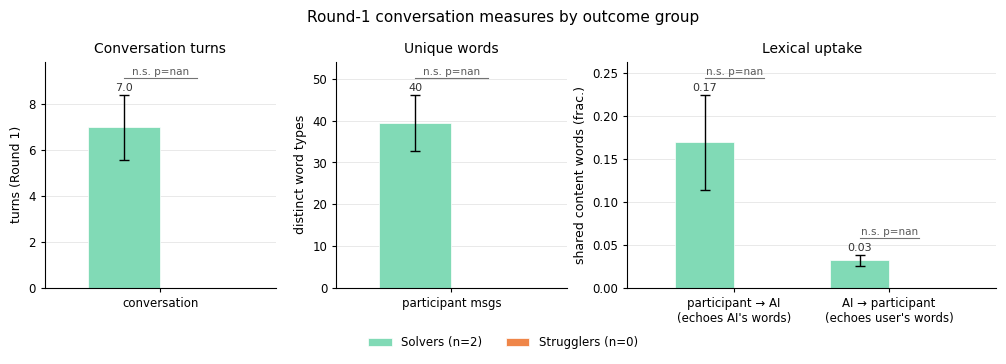

In [24]:
# --- R1 conversation measures: turns, unique words, lexical uptake (Solvers vs Strugglers) ---
# Three panels on the same population as the turns bar chart above.
#  * turns        -- exchanges in conversation_p15.jsonl (one line = one user+assistant pair)
#  * unique words -- distinct word TYPES across a participant's own R1 messages. Grows with
#                    turn count by construction, so the printed table also carries
#                    types-per-turn and TTR (types/tokens) as length-controlled companions.
#  * uptake       -- share of a speaker's CONTENT words that already appeared in the partner's
#                    immediately preceding message (Jaccard-style directional overlap):
#                      participant -> AI : user msg i vs assistant reply i-1  (needs >= 2 turns)
#                      AI -> participant : assistant reply i vs user msg i
#                    This is lexical uptake only -- it measures word reuse, not whether the
#                    idea was actually taken up. Domain vocabulary ("column", "diagonal") is
#                    unavoidable and inflates both directions; flip EXCLUDE_GAME_WORDS to see
#                    uptake with the Connect-Four vocabulary held out.
import re
from scipy.stats import mannwhitneyu

EXCLUDE_GAME_WORDS = False

STOP = set("""a an the and or but if then than so because as of at by for with about into
onto from to in on out up down over under again is are was were be been being am do does did
doing have has had having i you he she it we they me my your his her its our their this that
these those there here what which who whom when where why how all any both each few more most
other some such no nor not only own same too very can will just should now would could may
might must shall im ive youre dont doesnt didnt cant wont thats theres ill id well ok okay yes
yeah no oh hmm think thanks thank please sure lets let get got""".split())

GAME_WORDS = set("""column columns col cols row rows red reds yellow yellows move moves moving
play plays played playing win wins winning won lose loses lost board piece pieces game games
four three two connect diagonal diagonally vertical vertically horizontal horizontally block
blocks blocking opponent turn drop drops threat threats c1 c2 c3 c4 c5 c6 c7 r1 r2 r3 r4 r5
r6""".split())

TOKEN = re.compile(r"[a-z][a-z']*|\d+")

def _toks(s):
    return TOKEN.findall((s or "").lower())

def _content(s):
    """Content-word SET for uptake: stopwords out, 1-2 char tokens out."""
    drop = STOP | (GAME_WORDS if EXCLUDE_GAME_WORDS else set())
    return {w for w in _toks(s) if len(w) > 2 and w not in drop}

def _uptake(cur, prev):
    """Share of the current message's content words seen in the partner's previous one."""
    return len(cur & prev) / len(cur) if cur else np.nan

def convo_measures(pid):
    """Per-participant R1 conversation measures (nan where a measure is undefined)."""
    f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
    ex = [json.loads(l) for l in open(f) if l.strip()] if f.exists() else []
    if not ex:
        return dict(turns=0, types=0, tokens=0, ttr=np.nan,
                    types_per_turn=np.nan, up_user=np.nan, up_ai=np.nan)
    utoks = [t for e in ex for t in _toks(e.get("user"))]
    # participant echoing the AI's words (skips turn 0 -- no prior AI message to echo)
    up_user = [_uptake(_content(ex[i].get("user")), _content(ex[i - 1].get("assistant")))
               for i in range(1, len(ex))]
    # AI echoing the participant's words (defined on every exchange)
    up_ai = [_uptake(_content(e.get("assistant")), _content(e.get("user"))) for e in ex]
    nanmean = lambda v: np.nanmean(v) if len(v) and not np.all(np.isnan(v)) else np.nan
    return dict(turns=len(ex), types=len(set(utoks)), tokens=len(utoks),
                ttr=len(set(utoks)) / len(utoks) if utoks else np.nan,
                types_per_turn=len(set(utoks)) / len(ex),
                up_user=nanmean(up_user), up_ai=nanmean(up_ai))

GRP_C = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]
M = {nm: [convo_measures(p) for p in pids_] for nm, pids_, _ in GRP_C}

def _vals(nm, key):
    return np.array([m[key] for m in M[nm] if np.isfinite(m[key])], dtype=float)

print(f"{'group':<11}{'n':>4}{'turns':>9}{'types':>9}{'tokens':>9}{'types/turn':>12}"
      f"{'TTR':>7}{'up P->AI':>10}{'up AI->P':>10}")
for nm, pids_, _ in GRP_C:
    r = [_vals(nm, k).mean() for k in
         ("turns", "types", "tokens", "types_per_turn", "ttr", "up_user", "up_ai")]
    print(f"{nm:<11}{len(M[nm]):>4}{r[0]:>9.1f}{r[1]:>9.1f}{r[2]:>9.1f}{r[3]:>12.1f}"
          f"{r[4]:>7.2f}{r[5]:>10.2f}{r[6]:>10.2f}")
for k, lab in [("turns", "turns"), ("types", "unique words"), ("types_per_turn", "types/turn"),
               ("ttr", "TTR"), ("up_user", "uptake P->AI"), ("up_ai", "uptake AI->P")]:
    p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k), alternative="two-sided").pvalue
    print(f"  Mann-Whitney {lab:<14} p={p:.3f}")

def draw(ax, keys, xlabels, title, ylabel, fmt="{:.0f}", legend=False):
    """Grouped bars: one x-category per key, one bar per group. SEM error bars +
    Mann-Whitney bracket per category. y-limit is sized from the drawn bars."""
    W = 0.38 if len(keys) > 1 else 0.46
    tops = {}
    for gi, (nm, pids_, col) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            m, s = v.mean(), v.std() / np.sqrt(len(v))
            x = ci + (gi - 0.5) * W
            ax.bar(x, m, W, yerr=s, capsize=3.5, color=col, edgecolor="white", lw=0.5,
                   error_kw=dict(lw=1.0),
                   label=f"{nm} (n={len(pids_)})" if legend and ci == 0 else None)
            tops[gi, ci] = m + s
    PAD = 0.055 * max(tops.values())
    for gi, (nm, _, _) in enumerate(GRP_C):
        for ci, k in enumerate(keys):
            v = _vals(nm, k)
            ax.text(ci + (gi - 0.5) * W, tops[gi, ci] + 0.35 * PAD, fmt.format(v.mean()),
                    ha="center", fontsize=8, color="0.2")
    ytop = 0
    for ci, k in enumerate(keys):
        p = mannwhitneyu(_vals("Solvers", k), _vals("Strugglers", k),
                         alternative="two-sided").pvalue
        y = max(tops[0, ci], tops[1, ci]) + 1.6 * PAD
        ax.plot([ci - W / 2, ci + W / 2], [y, y], color="0.45", lw=0.8)
        stars = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
        ax.text(ci, y + 0.25 * PAD, f"{stars} p={p:.3f}", ha="center", fontsize=7.5, color="0.35")
        ytop = max(ytop, y + 1.5 * PAD)
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(xlabels, fontsize=8.5)
    ax.set_xlim(-0.5 - W / 2, len(keys) - 0.5 + W / 2)
    ax.set_ylim(0, ytop)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.tick_params(labelsize=8.5, length=3)
    ax.grid(axis="y", lw=0.4, color="0.85"); ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.5),
                         gridspec_kw=dict(width_ratios=[1, 1, 1.6]))
draw(axes[0], ["turns"], ["conversation"], "Conversation turns", "turns (Round 1)",
     fmt="{:.1f}", legend=True)
draw(axes[1], ["types"], ["participant msgs"], "Unique words", "distinct word types")
draw(axes[2], ["up_user", "up_ai"], ["participant → AI\n(echoes AI's words)",
                                     "AI → participant\n(echoes user's words)"],
     "Lexical uptake", "shared content words (frac.)", fmt="{:.2f}")
axes[2].set_ylim(0, min(1.0, axes[2].get_ylim()[1]))
fig.legend(*axes[0].get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=2,
           loc="lower center", bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Round-1 conversation measures by outcome group", fontsize=11)
fig.tight_layout(rect=(0, 0.06, 1, 0.97), pad=0.5); plt.show()


### Dialogue Acts

In [25]:
# Annotate each Round-1 user turn with the LLM panel (writes one file per participant).
# Slow + hits APIs (3 models x every user turn), so it SKIPS participants already
# annotated. Set OVERWRITE = True to force a re-run.
from dialogue_act_annotation import DialogueActSuite
import dotenv
dotenv.load_dotenv()

da = DialogueActSuite()
OVERWRITE = False

pids = sorted(all_candidates)
for n, pid in enumerate(pids, 1):
    convo_f = RECORDINGS_BASE / pid / "conversation_poc20260727.jsonl"
    if not convo_f.exists():
        continue
    out_f = RECORDINGS_BASE / pid / "annotated_conversation_poc20260727.jsonl"
    if out_f.exists() and out_f.stat().st_size > 0 and not OVERWRITE:
        print(f"[{n}/{len(pids)}] {pid[:8]} already annotated — skipping")
        continue

    turns = [json.loads(l) for l in open(convo_f) if l.strip()]
    print(f"[{n}/{len(pids)}] {pid[:8]} annotating {len(turns)} turns...")
    with open(out_f, "w") as w:
        for curr_l in turns:
            utt = (curr_l.get("user") or "").strip()
            curr_l["annotation_user"] = da(utterance=utt) if utt else None
            w.write(json.dumps(curr_l) + "\n")

14:25:31 - LiteLLM:WARNING: common_utils.py:979 - litellm: could not pre-load bedrock-runtime response stream shape — Bedrock event-stream decoding will be unavailable. Error: No module named 'botocore'
14:25:31 - LiteLLM:WARNING: common_utils.py:24 - litellm: could not pre-load sagemaker-runtime response stream shape — SageMaker event-stream decoding will be unavailable. Error: No module named 'botocore'


[1/2] 5b50881a annotating 9 turns...
[2/2] 62733b8e annotating 5 turns...


In [29]:
# Build a tidy LONG dataframe: one row per (turn, dialogue act).
import pandas as pd

def normalize_ann(ann):
    """Canonicalize a stored annotation. Handles both the current dict form and
    the legacy tuple form [consensus, votes, per_model] (serialized as a list) so
    old annotated files don't need re-running."""
    if ann is None:
        return None
    if isinstance(ann, dict):
        return ann
    consensus, votes, per_model = ann                       # legacy list form
    n_valid = sum(v is not None for v in per_model.values())
    confidence = {a: votes[a] / n_valid for a in votes} if n_valid else {}
    no_majority = not consensus and bool(votes)
    final = consensus if consensus else [a for a in votes]  # no-majority -> union
    return {"final": final, "consensus": consensus, "votes": votes,
            "confidence": confidence, "per_model": per_model, "n_valid": n_valid,
            "no_majority": no_majority, "needs_review": no_majority or n_valid < 2,
            "arbiter_used": False}

group_of = {**{p: "win" for p in win_pid}, **{p: "won" for p in good_pid}, **{p: "lost" for p in bad_pid}}

# Manual relabels for acts that don't fit this human<->AI setting.
# "Correct Answer" (student answering a tutor) misfires on terse move
# statements like "Column 4" -> treat as Think Aloud.
ACT_REMAP = {"Correct Answer": "Think Aloud", "Social Coordination Action": "Metacomment", "Forced Choice": "Metacomment"}

rows = []
for pid in all_candidates:
    convo_f = RECORDINGS_BASE / pid / "annotated_conversation_poc20260727.jsonl"
    if not convo_f.exists():
        continue
    for i, l in enumerate(open(convo_f)):
        curr_l = json.loads(l)
        ann = normalize_ann(curr_l.get("annotation_user"))
        acts = [ACT_REMAP.get(a, a) for a in (ann["final"] if ann else [])]
        acts = list(dict.fromkeys(acts))                      # dedup after remap
        conf = {ACT_REMAP.get(k, k): v for k, v in (ann.get("confidence", {}) if ann else {}).items()}
        needs_review = bool(ann and ann.get("needs_review"))
        # one row per act; keep turns with no acts as a single utt_type=None row
        for act in (acts or [None]):
            rows.append({
                "pid": pid,
                "utt": curr_l.get("user"),
                "utt_type": act,
                "conf": conf.get(act) if act else None,
                "needs_review": needs_review,
                "utt_ind": i,
                "outcome": group_of.get(pid, "MISSING"),
            })

df = pd.DataFrame(rows)
print(f"{len(df)} rows | {df['pid'].nunique()} participants | "
      f"{df['needs_review'].mean():.0%} of rows flagged needs_review")
df.head(n=5)

18 rows | 2 participants | 0% of rows flagged needs_review


,pid,utt,utt_type,conf,needs_review,utt_ind,outcome
0,p150,is H1 a good move for me?,Common Ground Question,1.0,False,0,won
1,p150,"oh, I see. Then how about a7?",Conversational Acknowledgment,1.0,False,1,won
2,p150,"oh, I see. Then how about a7?",Common Ground Question,1.0,False,1,won
3,p150,why isn't H1 a legal move right now?,Knowledge Deficit Question,1.0,False,2,won
4,p150,I get it now. So I kind of like C8 because it...,Think Aloud,1.0,False,3,won


In [30]:
df.loc[df["outcome"] == "won"]["utt_type"].value_counts()

utt_type
Common Ground Question           8
Think Aloud                      4
Solution Request                 3
Conversational Acknowledgment    2
Knowledge Deficit Question       1
Name: count, dtype: int64

In [31]:
df.loc[df["outcome"] == "lost"]["utt_type"].value_counts()

Series([], Name: count, dtype: int64)

### Dialogue-act frequency by outcome group

Rate = **acts of a given type per user turn**, computed per participant then averaged within each group so everyone counts equally regardless of how many turns they took (winners take fewer turns, so raw totals would under-represent them). Error bars = SEM across participants.

KeyError: 'lost'

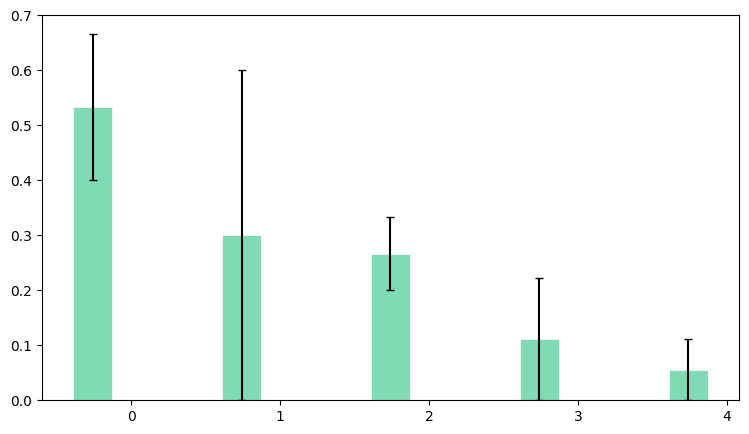

In [32]:
# Per-participant, per-turn rate of each dialogue act, averaged within group.
turns_per_pid = df.groupby("pid")["utt_ind"].nunique()          # user turns per participant
acts_df = df.dropna(subset=["utt_type"])

cnt = acts_df.groupby(["pid", "utt_type"]).size().rename("n").reset_index()
cnt["rate"] = cnt["n"] / cnt["pid"].map(turns_per_pid)

# participants x acts table of rates (0 where a participant never used that act);
# reindex over ALL pids so participants with no coded acts still count as zeros
rate_tbl = cnt.pivot_table(index="pid", columns="utt_type", values="rate", fill_value=0)
rate_tbl = rate_tbl.reindex(sorted(df["pid"].unique()), fill_value=0)
rate_tbl["outcome"] = rate_tbl.index.map(group_of)

acts_order = rate_tbl.drop(columns="outcome").sum().sort_values(ascending=False).index.tolist()
grp_mean = rate_tbl.groupby("outcome")[acts_order].mean()
grp_sem = rate_tbl.groupby("outcome")[acts_order].sem()
n_by = rate_tbl["outcome"].value_counts()

GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}
fig, ax = plt.subplots(figsize=(max(9, 0.9 * len(acts_order) + 3), 5))
x = np.arange(len(acts_order)); w = 0.26
for gi, (g, col) in enumerate(GRP):
    ax.bar(x + (gi - 1) * w, grp_mean.loc[g], w, yerr=grp_sem.loc[g], capsize=3,
           color=col, label=f"{DISP.get(g, g)} (n={n_by.get(g, 0)})", edgecolor="white", lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(acts_order, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("mean acts per user turn")
ax.set_title("Dialogue-act frequency by outcome group (per-participant normalized)")
ax.legend(); plt.tight_layout(); plt.show()

### How far apart the two outcomes sit (dumbbell)

One row per dialogue act: a dot for **Solvers** (green, score ≥ 2) and **Strugglers** (red), each = that group's **mean share of a participant's acts (%)**, joined by a gray bar whose length is the gap. **Longer bar = the act separates Solvers from Strugglers more.** Sorted with the biggest separators on top (n per group is in the legend; treat small gaps as noise).

/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/171476912.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = mannwhitneyu(share.loc[won_ids, a].values,
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/171476912.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = mannwhitneyu(share.loc[won_ids, a].values,
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/171476912.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, p = mannwhitneyu(share.loc[won_ids, a].values,
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/171476912.py:24: SmallSampleWarning: One or more sample arguments is too small; all returned values w

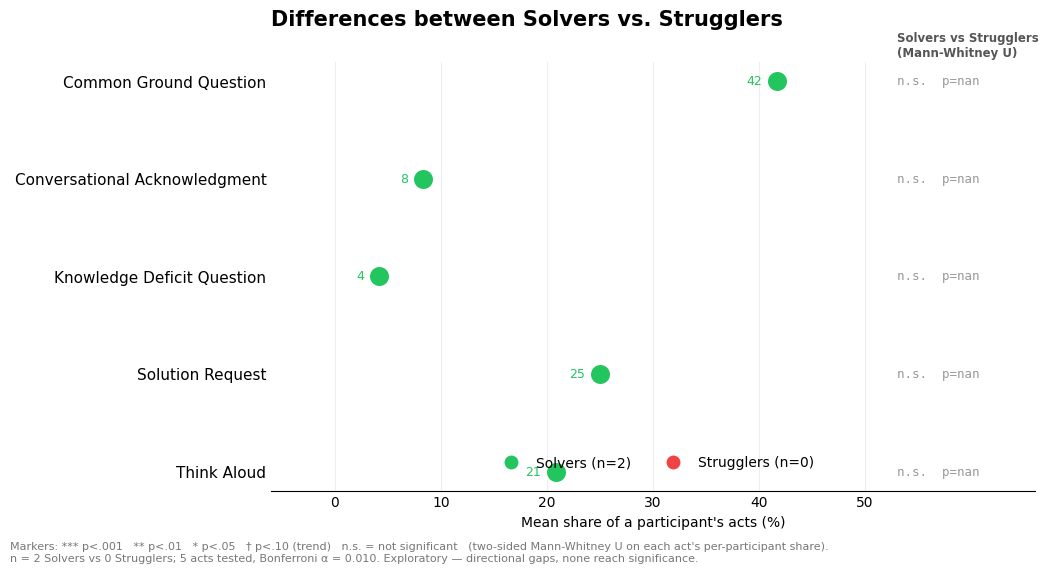

In [33]:
# Dumbbell: won vs lost separation on each dialogue act (+ significance markers).
# metric = mean share of a participant's acts (%). Labels sit on the OUTER side of
# each dot (smaller->left, larger->right) so they never overlap when dots are close.
# Right-hand column: Mann-Whitney U p-value per act (won vs lost share) + stars.
# Population is unchanged: good_pid (won, score>=2) vs bad_pid (lost) -- the original set.
from scipy.stats import mannwhitneyu
import matplotlib.transforms as mtransforms

LAB = [("Solvers", good_pid, "#22c55e"), ("Strugglers", bad_pid, "#ef4444")]
acts_all = df.dropna(subset=["utt_type"])
tot = acts_all.groupby("pid").size()
cnt = (acts_all.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))
share = 100 * cnt.div(tot, axis=0).fillna(0)                 # pid x act (% of that pid's acts)

won_ids = [p for p in good_pid if p in share.index]          # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

def gmean(pids, a):
    idx = [p for p in pids if p in share.index]
    return share.loc[idx, a].mean()

def mwu_p(a):
    _, p = mannwhitneyu(share.loc[won_ids, a].values,
                        share.loc[lost_ids, a].values, alternative="two-sided")
    return p

def sig_mark(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "†"                            # dagger = trend
    return "n.s."

acts = sorted(share.columns, key=lambda a: abs(gmean(good_pid, a) - gmean(bad_pid, a)), reverse=True)
y = np.arange(len(acts))
PAD = 1.4                                                     # horizontal gap between dot and its label
alpha_bonf = 0.05 / len(acts)                                # multiple-comparison threshold

fig, ax = plt.subplots(figsize=(10.5, 0.7 * len(acts) + 2))
XR = max(66, share.mean().max() + 22)                        # room for the significance column
SIG_X = XR - 13                                              # left edge of the p-value column
for yi, a in zip(y, acts):
    ranked = sorted(LAB, key=lambda t: gmean(t[1], a))       # ascending by value
    (lo_lab, lo_p, lo_c), (hi_lab, hi_p, hi_c) = ranked
    lo, hi = gmean(lo_p, a), gmean(hi_p, a)
    ax.hlines(yi, lo, hi, color="#d9d9d9", lw=6, zorder=1, capstyle="round")
    for lab, pids, col in LAB:
        ax.scatter(gmean(pids, a), yi, s=230, color=col, edgecolor="white", lw=1.5, zorder=3)
    ax.text(lo - PAD, yi, f"{lo:.0f}", ha="right", va="center", fontsize=9, color=lo_c)   # smaller -> left
    ax.text(hi + PAD, yi, f"{hi:.0f}", ha="left", va="center", fontsize=9, color=hi_c)    # larger  -> right
    # significance marker (Mann-Whitney U, won vs lost share)
    p = mwu_p(a)
    is_sig = p < 0.05
    ax.text(SIG_X, yi, f"{sig_mark(p):>4}  p={p:.2f}", ha="left", va="center", fontsize=9,
            family="monospace", color=("#111" if is_sig else "#999"),
            fontweight=("bold" if is_sig else "normal"))
ax.set_yticks(y); ax.set_yticklabels(acts, fontsize=11)
ax.invert_yaxis()
ax.set_xlim(-6, XR)
ax.set_xticks([t for t in range(0, 51, 10)])                 # ticks span the data range only
ax.set_xlabel("Mean share of a participant's acts (%)")
ax.set_title("Differences between Solvers vs. Strugglers", fontsize=15, fontweight="bold", loc="left", pad=26)
# significance-column header (data x, axes-fraction y so it sits just above the top row)
trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
ax.text(SIG_X, 1.005, "Solvers vs Strugglers\n(Mann-Whitney U)", transform=trans, ha="left", va="bottom",
        fontsize=8.5, color="#555", fontweight="bold")
ax.grid(axis="x", color="#eee", zorder=0); ax.set_axisbelow(True)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
ax.tick_params(length=0)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=11, mfc=col, mec="white",
                      label=f"{lab} (n={len([p for p in pids if p in share.index])})")
           for lab, pids, col in LAB]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=10, ncol=2,
          bbox_to_anchor=(0.28, 0.02))
fig.text(0.01, -0.03,
         f"Markers: *** p<.001   ** p<.01   * p<.05   † p<.10 (trend)   n.s. = not significant   "
         f"(two-sided Mann-Whitney U on each act's per-participant share).\n"
         f"n = {len(won_ids)} Solvers vs {len(lost_ids)} Strugglers; {len(acts)} acts tested, "
         f"Bonferroni α = {alpha_bonf:.3f}. Exploratory — directional gaps, none reach significance.",
         fontsize=8, color="#777", ha="left")
plt.tight_layout(); plt.show()


### Solvers vs Strugglers: t-test per dialogue act

Independent (Welch, unequal-variance) t-test on each act's **share of a participant's acts (%)**, Solvers (score ≥ 2) vs Strugglers. Participants who never used an act count as 0%. Also reports Mann-Whitney U (nonparametric — safer here since shares are bounded and zero-heavy) and Cohen's d (effect size).

*Caveats:* n = 17 / 15, and testing ~6 acts means multiple comparisons — the Bonferroni threshold is α = 0.05 / (#acts). Treat this as exploratory; with this n, expect little to survive correction.

In [34]:
# Permutation test (+ Mann-Whitney, Cohen's d) on per-participant act share, won vs lost.
# Swapped from Welch's t-test: these shares are bounded, zero-heavy proportions from tiny
# per-participant act counts (~1-8), so at this n a label-permutation test on the mean
# difference is more defensible than a t-test (no normality assumption).
from scipy import stats

acts_all = df.dropna(subset=["utt_type"])
tot = acts_all.groupby("pid").size()
cnt = (acts_all.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
         .reindex(sorted(df["pid"].unique()), fill_value=0))
share = 100 * cnt.div(tot, axis=0).fillna(0)                 # pid x act (% of that pid's acts)
won_ids = [p for p in good_pid if p in share.index]         # score >= 2
lost_ids = [p for p in bad_pid if p in share.index]

# Combined "reasoning" acts proportion (share of a participant's acts that are any of these).
REASONING_ACTS = ["Think Aloud"]
reasoning_share = share[[a for a in REASONING_ACTS if a in share.columns]].sum(axis=1)

# Variables to test: each individual act's share, plus the combined reasoning proportion.
# variables = [(a, share[a]) for a in share.columns]
variables = []
variables.append(("Reasoning (CGQ+TA)", reasoning_share))

def cohend(x, z):
    nx, nz = len(x), len(z)
    sp = np.sqrt(((nx - 1) * x.var(ddof=1) + (nz - 1) * z.var(ddof=1)) / (nx + nz - 2))
    return (x.mean() - z.mean()) / sp if sp > 0 else np.nan

def perm_test(x, z, n_perm=20000, seed=0):
    """Two-sided permutation test on the difference in group means (label shuffling)."""
    obs = x.mean() - z.mean()
    pooled = np.concatenate([x, z]); nx = len(x)
    rng = np.random.default_rng(seed)
    ge = 0
    for _ in range(n_perm):
        perm = rng.permutation(pooled)
        d = perm[:nx].mean() - perm[nx:].mean()
        if abs(d) >= abs(obs) - 1e-12:
            ge += 1
    return obs, (ge + 1) / (n_perm + 1)                      # +1 = the observed labeling

rows = []
for a, series in variables:
    x, z = series.loc[won_ids].values, series.loc[lost_ids].values
    obs, p_perm = perm_test(x, z)                            # permutation (mean diff)
    _, pu = stats.mannwhitneyu(x, z, alternative="two-sided")
    rows.append((a, x.mean(), z.mean(), obs, p_perm, pu, cohend(x, z)))
rows.sort(key=lambda r: r[4])                                # by permutation p

alpha_bonf = 0.05 / len(rows)
print(f"Permutation test (mean diff, 20k shuffles): Solvers (n={len(won_ids)}) vs Strugglers (n={len(lost_ids)})   "
      f"Bonferroni alpha = {alpha_bonf:.4f}\n")
print(f"{'act':>28} {'Solv%':>6} {'Strug%':>6} {'diff':>6} {'perm_p':>7} {'MWU_p':>7} {'d':>6}")
for a, w, l, dff, p, pu, d in rows:
    star = "*" if p < alpha_bonf else ("." if p < 0.05 else " ")
    print(f"{a:>28} {w:6.1f} {l:6.1f} {dff:+6.1f} {p:7.3f} {pu:7.3f} {d:+6.2f} {star}")
print("\n  * p < Bonferroni alpha    . p < 0.05 (uncorrected)")


Permutation test (mean diff, 20k shuffles): Solvers (n=2) vs Strugglers (n=0)   Bonferroni alpha = 0.0500

                         act  Solv% Strug%   diff  perm_p   MWU_p      d
          Reasoning (CGQ+TA)   20.8    nan   +nan   0.000     nan   +nan *

  * p < Bonferroni alpha    . p < 0.05 (uncorrected)


/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/3740400600.py:31: RuntimeWarning: Mean of empty slice
  obs = x.mean() - z.mean()
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/3740400600.py:37: RuntimeWarning: Mean of empty slice
  d = perm[:nx].mean() - perm[nx:].mean()
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/3740400600.py:46: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  _, pu = stats.mannwhitneyu(x, z, alternative="two-sided")
/var/folders/st/lspvytf51f5c21v94mh8xj080000gn/T/ipykernel_62379/3740400600.py:47: RuntimeWarning: Mean of empty slice
  rows.append((a, x.mean(), z.mean(), obs, p_perm, pu, cohend(x, z)))
/var/f

In [40]:
df.to_csv("participant_utterances.csv", index=False)

# AI-assistant rating by outcome group (Solvers / Strugglers)

From `assistant_helpfulness.csv` — the post-round survey on the AI assistant. Two items on a 5-point Likert (strongly disagree=1 … strongly agree=5):

- **consistent-with-intent** — "responses were consistent with the intentions of my questions"
- **easy-to-use** — "the AI assistant was easy to use"

Each participant is tagged with their Round-2 outcome label (Solvers / Strugglers). Duplicate submissions are resolved to the participant's **first** (Round-1) response; respondents not among our 35 both-round completers are unlabeled and excluded from group means.

survey respondents: 90   labeled (in our 35 completers): 0
labeled completers with NO survey row (5): 56f29eff[Strugglers], 5d61a6ec[Strugglers], 5de84cca[Strugglers], 5deb638b[Strugglers], 6140ef8d[Solvers]

 participant       group  intent  ease

    Solvers (n=0):  intent nan   ease nan
 Strugglers (n=0):  intent nan   ease nan


/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/siyanli/Documents/CITRUS/document_study_og/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid val

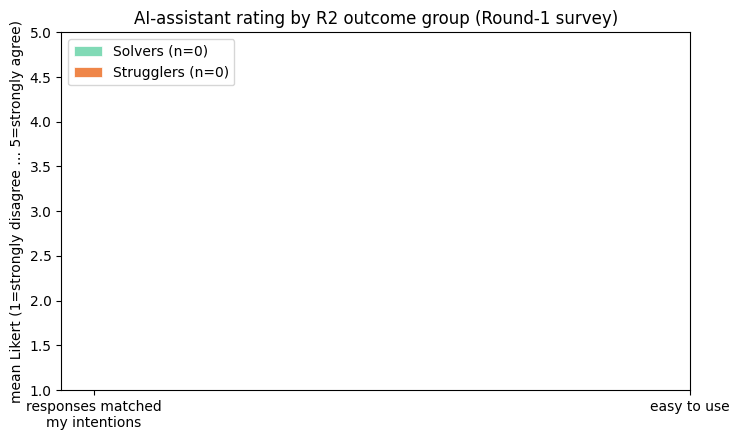

In [42]:
# --- Join assistant_helpfulness.csv with Solvers/Strugglers labels ---
import csv

LIKERT = {"strongly disagree": 1, "disagree": 2, "neutral": 3, "agree": 4, "strongly agree": 5}
GROUP_OF = {**{p: "won" for p in good_pid}, **{p: "win" for p in win_pid}, **{p: "lost" for p in bad_pid}}
DISP = {"won": "Solvers", "win": "Solvers", "lost": "Strugglers"}

rows = list(csv.DictReader(open("assistant_helpfulness.csv")))
cols = list(rows[0].keys())
pid_col, intent_col, ease_col = cols[1], cols[2], cols[3]   # ID, "consistent with intentions", "easy to use"

# one record per participant = their FIRST (Round-1) submission
per_pid = {}
for r in rows:
    pid = r[pid_col].strip()
    if pid in per_pid:
        continue
    per_pid[pid] = {
        "intent": LIKERT.get(r[intent_col].strip().lower()),
        "ease":   LIKERT.get(r[ease_col].strip().lower()),
        "group":  GROUP_OF.get(pid),
    }

labeled = {p: v for p, v in per_pid.items() if v["group"]}
missing = sorted(set(GROUP_OF) - set(per_pid))          # labeled completers with no survey row
print(f"survey respondents: {len(per_pid)}   labeled (in our 35 completers): {len(labeled)}")
if missing:
    print(f"labeled completers with NO survey row ({len(missing)}): "
          + ", ".join(f"{p[:8]}[{DISP.get(GROUP_OF[p], GROUP_OF[p])}]" for p in missing))

# per-participant labeled table
print(f"\n{'participant':>12} {'group':>11} {'intent':>7} {'ease':>5}")
for pid, v in sorted(labeled.items(), key=lambda kv: (kv[1]["group"], kv[0])):
    print(f"{pid[:12]:>12} {DISP.get(v['group'], v['group']):>11} {str(v['intent']):>7} {str(v['ease']):>5}")

# group means + plot
GRP = [("won", "#81dab6"), ("lost", "#ef8649")]
METRICS = [("intent", "responses matched\nmy intentions"), ("ease", "easy to use")]
print()
fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(METRICS)); w = 0.26
for gi, (grp, col) in enumerate(GRP):
    vs = [v for v in labeled.values() if v["group"] == grp]
    means = [np.mean([v[m] for v in vs if v[m] is not None]) for m, _ in METRICS]
    sems = [np.std([v[m] for v in vs if v[m] is not None]) / np.sqrt(sum(v[m] is not None for v in vs))
            for m, _ in METRICS]
    ax.bar(x + (gi - 1) * w, means, w, yerr=sems, capsize=3, color=col,
           label=f"{DISP.get(grp, grp)} (n={len(vs)})", edgecolor="white", lw=0.5)
    print(f"{DISP.get(grp, grp):>11} (n={len(vs)}):  intent {means[0]:.2f}   ease {means[1]:.2f}")
ax.set_xticks(x); ax.set_xticklabels([lbl for _, lbl in METRICS])
ax.set_ylim(1, 5); ax.set_ylabel("mean Likert (1=strongly disagree … 5=strongly agree)")
ax.set_title("AI-assistant rating by R2 outcome group (Round-1 survey)")
ax.legend(); plt.tight_layout(); plt.show()

# Time per Puzzle

In [43]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_poc20260727.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "prompt_task.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times),  max(times), min(times)

print("P1 SOLVERS === ", measure_time(good_pid))
print("P1 STRUGGLERS ===", measure_time(bad_pid))


P1 SOLVERS ===  (np.float64(419.392628), np.float64(419.392628), np.float64(0.0), 419.392628, 419.392628)
P1 STRUGGLERS === (np.float64(413.751828), np.float64(419.44996349999997), np.float64(132.4004185880771), 547.999865, 268.10752)


In [187]:
import os
import datetime

def _ts(s):
    return datetime.datetime.fromisoformat(s)

def measure_time(pids):
    times = []
    for pid in pids:
        moves_f  = RECORDINGS_BASE / pid / "moves_pw4p6.jsonl"
        prompt_f = RECORDINGS_BASE / pid / "post_survey_p15.json"
        if os.path.exists(moves_f) and os.path.exists(prompt_f):
            lines = [json.loads(l) for l in open(moves_f) if l.strip()]
            start = _ts(json.load(open(prompt_f))["submitted_at"])   # approx puzzle start
            end   = _ts(lines[-1]["ts"])                             # last move
            times.append((end - start).total_seconds())
        else:
            times.append(None)
    times = [x for x in times if x is not None]
    return np.mean(times), np.median(times), np.std(times),  max(times), min(times)

print("P2 SOLVERS === ", measure_time(good_pid))
print("P2 STRUGGLERS === ", measure_time(bad_pid))

P2 SOLVERS ===  (np.float64(54.01183538983051), np.float64(44.696448), np.float64(26.89266030431281), 148.704112, 18.402766)
P2 STRUGGLERS ===  (np.float64(65.34647847916666), np.float64(58.101909000000006), np.float64(30.941191106977875), 153.589989, 17.764747)


Solvers    Round 1 (p15, with AI) n=59  mean= 224.5s  median= 205.1s  sd=119.8s
Strugglers Round 1 (p15, with AI) n=47  mean= 225.3s  median= 210.4s  sd=101.3s  [dropped 1 non-positive]
Solvers    Round 2 (w4p6, solo)   n=59  mean=  54.0s  median=  44.7s  sd= 26.9s
Strugglers Round 2 (w4p6, solo)   n=48  mean=  65.3s  median=  58.1s  sd= 30.9s


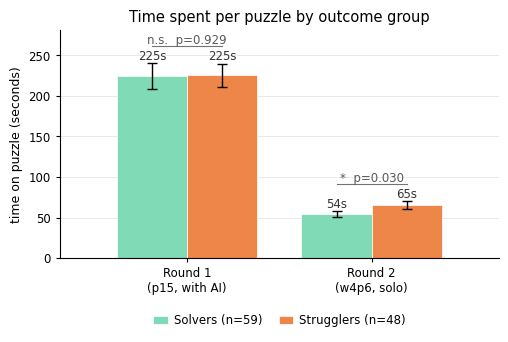

In [194]:
# --- Time spent per puzzle: Solvers vs Strugglers (grouped bars) ---
# Same start/end convention as the two cells above: start = the survey submitted right
# before the puzzle (prompt_task.json -> R1 p15, post_survey_p15.json -> R2 pw4p6),
# end = the timestamp of the participant's last move.
# NOTE: a few R1 records have that survey stamped AFTER the first move (flow/clock
# artifact -> negative duration; the R1 min above is -249s). Those are dropped here and
# the count is printed, so they don't silently drag the means down.
from scipy.stats import mannwhitneyu

PUZZLES = [("Round 1\n(p15, with AI)", "moves_p15.jsonl",   "prompt_task.json"),
           ("Round 2\n(w4p6, solo)",   "moves_pw4p6.jsonl", "post_survey_p15.json")]
GRP_T = [("Solvers", good_pid, "#81dab6"), ("Strugglers", bad_pid, "#ef8649")]

def times_list(pids, moves_name, start_name):
    """Per-participant seconds on a puzzle; returns (valid_times, n_dropped)."""
    out, dropped = [], 0
    for pid in pids:
        moves_f, start_f = RECORDINGS_BASE / pid / moves_name, RECORDINGS_BASE / pid / start_name
        if not (moves_f.exists() and start_f.exists()):
            continue
        lines = [json.loads(l) for l in open(moves_f) if l.strip()]
        if not lines:
            continue
        secs = (_ts(lines[-1]["ts"]) - _ts(json.load(open(start_f))["submitted_at"])).total_seconds()
        if secs <= 0:
            dropped += 1
        else:
            out.append(secs)
    return out, dropped

# Collect every number first, so the y-axis is sized from what actually gets DRAWN
# (bar tops + brackets) rather than from raw per-participant maxima -- that mismatch is
# what left ~75s of dead headroom and floated the Round-2 bracket below its own bars.
stats, pvals = {}, []
for pi, (plab, mv, st) in enumerate(PUZZLES):
    for gi, (nm, pids_, _) in enumerate(GRP_T):
        t, drop = times_list(pids_, mv, st)
        stats[gi, pi] = (np.mean(t), np.std(t) / np.sqrt(len(t)), len(t))
        print(f"{nm:<10} {plab.replace(chr(10), ' '):<22} n={len(t):2d}  mean={np.mean(t):6.1f}s  "
              f"median={np.median(t):6.1f}s  sd={np.std(t):5.1f}s"
              + (f"  [dropped {drop} non-positive]" if drop else ""))
    pvals.append(mannwhitneyu(times_list(good_pid, mv, st)[0],
                              times_list(bad_pid, mv, st)[0], alternative="two-sided").pvalue)

W = 0.38                                             # bar width; pair spans 2W of a 1.0 step
tops = {(gi, pi): m + s for (gi, pi), (m, s, _) in stats.items()}
PAD = 0.055 * max(tops.values())                     # one clearance unit for labels/brackets

fig, ax = plt.subplots(figsize=(5.0, 3.4))
for gi, (nm, pids_, col) in enumerate(GRP_T):
    for pi in range(len(PUZZLES)):
        x = pi + (gi - 0.5) * W
        mean, sem, n = stats[gi, pi]
        ax.bar(x, mean, W, yerr=sem, capsize=3.5, color=col, edgecolor="white", lw=0.5,
               error_kw=dict(lw=1.0), label=f"{nm} (n={len(pids_)})" if pi == 0 else None)
        ax.text(x, mean + sem + 0.35 * PAD, f"{mean:.0f}s", ha="center", fontsize=8.5, color="0.2")

# Mann-Whitney U per puzzle, bracket anchored just above THAT pair's taller bar
ytop = 0
for pi, p in enumerate(pvals):
    y = max(tops[0, pi], tops[1, pi]) + 1.6 * PAD
    ax.plot([pi - W / 2, pi + W / 2], [y, y], color="0.45", lw=0.8)
    stars = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    ax.text(pi, y + 0.25 * PAD, f"{stars}  p={p:.3f}", ha="center", fontsize=8.5, color="0.35")
    ytop = max(ytop, y + 1.5 * PAD)                  # room for the annotation text itself

ax.set_xticks(range(len(PUZZLES)))
ax.set_xticklabels([p[0] for p in PUZZLES], fontsize=9)
ax.set_xlim(-0.5 - W / 2, len(PUZZLES) - 1 + 0.5 + W / 2)   # trim the outer margins
ax.set_ylim(0, ytop)
ax.set_ylabel("time on puzzle (seconds)", fontsize=9)
ax.set_title("Time spent per puzzle by outcome group", fontsize=10.5)
ax.tick_params(labelsize=8.5, length=3)
ax.grid(axis="y", lw=0.4, color="0.85"); ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
# Legend below the axis: the upper-right lane it used to sit in was the dead space.
ax.legend(frameon=False, fontsize=8.5, ncol=2, loc="upper center",
          bbox_to_anchor=(0.5, -0.20), columnspacing=1.4, handlelength=1.2, handletextpad=0.5)
fig.tight_layout(pad=0.4); plt.show()


## OLS: R1 reasoning-act engagement → R2 performance

Regress each R2 outcome on the share of a participant's R1 dialogue acts that are *reasoning* acts (Common Ground Question + Think Aloud + Knowledge-Deficit Question). Exploratory / single-predictor; IV is from the AI-assisted R1 conversation, DV from the unassisted R2.

In [ ]:
# --- OLS: does R1 reasoning-act engagement predict R2 performance? ---
# IV: share of a participant's R1 dialogue acts that are "reasoning" acts
#     (Common Ground Question + Think Aloud + Knowledge Deficit Question).
# DV: R2 outcome -- reported for flat score, difficulty-weighted selectivity, and
#     the winning-line score. Manual OLS (numpy/scipy) so there's no statsmodels dep.
from scipy import stats as _stats

# REASONING_ACTS = ["Common Ground Question", "Think Aloud", "Knowledge Deficit Question"]
REASONING_ACTS = ["Common Ground Question", "Think Aloud"]


# per-participant reasoning-act share (proportion of that participant's acts)
_acts = df.dropna(subset=["utt_type"])
_tot = _acts.groupby("pid").size()
_cnt = (_acts.groupby(["pid", "utt_type"]).size().unstack(fill_value=0)
             .reindex(sorted(df["pid"].unique()), fill_value=0))
_share = _cnt.div(_tot, axis=0).fillna(0)                       # proportion in [0, 1]
reasoning_prop = _share[[a for a in REASONING_ACTS if a in _share.columns]].sum(axis=1)

# assemble (reasoning_prop, R2 outcomes) for participants with a gradable R2 file
recs = []
for pid in reasoning_prop.index:
    f2 = RECORDINGS_BASE / pid / score_r2
    if not f2.exists():
        continue
    j2 = json.load(open(f2))
    f3 = RECORDINGS_BASE / pid / score_r3
    j3 = json.load(open(f3))
    recs.append((reasoning_prop[pid], j2.get("final_margin") + j3.get("final_margin")))

X = np.array([r[0] for r in recs], float)
DVs = {"flat R2 score": np.array([r[1] for r in recs], float)}

def ols1(x, y):
    """Simple OLS y ~ 1 + x with t/F tests (no statsmodels dependency)."""
    m = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[m], y[m]; n = len(y)
    Xn = np.column_stack([np.ones(n), x])
    beta, *_ = np.linalg.lstsq(Xn, y, rcond=None)
    resid = y - Xn @ beta; dof = n - 2
    ss_res = float(resid @ resid); ss_tot = float(((y - y.mean()) ** 2).sum())
    r2 = 1 - ss_res / ss_tot if ss_tot else float("nan")
    se = np.sqrt(np.diag((ss_res / dof) * np.linalg.inv(Xn.T @ Xn)))
    tv = beta / se
    pv = 2 * (1 - _stats.t.cdf(np.abs(tv), dof))
    r, _ = _stats.pearsonr(x, y); rho, rhop = _stats.spearmanr(x, y)
    return dict(n=n, coef=beta[1], se=se[1], t=tv[1], p=pv[1], r2=r2, r=r, rho=rho, rhop=rhop)

print("OLS: R2 outcome ~ R1 reasoning-act share  (IV = CGQ + ThinkAloud proportion)")
print(f"reasoning share: mean={X.mean():.3f} sd={X.std(ddof=1):.3f}  (n={len(X)})\n")
print(f"{'DV':>34} {'n':>3} {'coef':>7} {'SE':>6} {'t':>6} {'p':>7} {'R2':>6} {'r':>7} {'rho_p':>7}")
for name, y in DVs.items():
    o = ols1(X, y)
    star = " *" if o["p"] < 0.05 else ("  ." if o["p"] < 0.10 else "")
    print(f"{name:>34} {o['n']:>3} {o['coef']:+7.3f} {o['se']:6.3f} {o['t']:6.2f} "
          f"{o['p']:7.4f} {o['r2']:6.3f} {o['r']:+7.3f} {o['rhop']:7.4f}{star}")
print("\n  * p<0.05   . p<0.10   |  IV from R1 (AI-assisted) conversation, DV from unassisted R2")


OLS: R2 outcome ~ R1 reasoning-act share  (IV = CGQ + ThinkAloud proportion)
reasoning share: mean=0.551 sd=0.305  (n=5)

                                DV   n    coef     SE      t       p     R2       r   rho_p
                     flat R2 score   5  -4.466 14.331  -0.31  0.7758  0.031  -0.177  0.5528

  * p<0.05   . p<0.10   |  IV from R1 (AI-assisted) conversation, DV from unassisted R2


In [47]:
# --- Solvers vs Strugglers: IT-occupation & frequent-GenAI-use differences (Pearson chi-square) ---
# won = good_pid (high R2), lost = bad_pid (low R2). Two 2x2 tests. Binary splits keep
# cell counts high enough for the chi-square approximation (min-expected printed as a check).
from scipy import stats as _stats

# "few times a week and above" (weekly counts as INFREQUENT -- it's below few_times_week)
FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}

def _demo(pids):
    out = []
    for pid in pids:
        f = RECORDINGS_BASE / pid / "demographics.json"
        if f.exists():
            out.append(json.load(open(f)))
    return out

_won, _lost = _demo(good_pid), _demo(bad_pid)

def _chi2_2x2(field, pred, label, pos_name, neg_name):
    def counts(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        pos = sum(1 for v in vals if pred(v))
        return pos, len(vals) - pos, len(vals)
    wp, wn, wt = counts(_won)
    lp, ln, lt = counts(_lost)
    table = np.array([[wp, wn], [lp, ln]])
    chi2, p, dof, exp = _stats.chi2_contingency(table, correction=False)   # Pearson (no Yates)
    v = np.sqrt(chi2 / table.sum())                                        # Cramer's V (= phi for 2x2)
    print(f"\n{label}  (Pearson chi-square, 2x2)")
    print(f"  Solvers    (n={wt}): {pos_name}={wp} ({100*wp/wt:.0f}%)   {neg_name}={wn}")
    print(f"  Strugglers (n={lt}): {pos_name}={lp} ({100*lp/lt:.0f}%)   {neg_name}={ln}")
    print(f"  chi2={chi2:.2f}, dof={dof}, p={p:.4f}, Cramer's V={v:.2f}, "
          f"min expected={exp.min():.1f}{'  *significant' if p < 0.05 else ''}")
    if exp.min() < 5:
        print("  (min expected count < 5 -> chi-square approximate here; Fisher's exact would be safer)")

print(f"Solvers n={len(_won)}  |  Strugglers n={len(_lost)}")
_chi2_2x2("occupation", lambda v: v == "it",
          "IT vs non-IT occupation", "IT", "non-IT")
_chi2_2x2("genai_usage", lambda v: v in FREQUENT_GENAI,
          "Frequent (>= few times/week) vs infrequent GenAI use", "frequent", "infrequent")


Solvers n=1  |  Strugglers n=4

IT vs non-IT occupation  (Pearson chi-square, 2x2)
  Solvers    (n=1): IT=0 (0%)   non-IT=1
  Strugglers (n=4): IT=1 (25%)   non-IT=3
  chi2=0.31, dof=1, p=0.5762, Cramer's V=0.25, min expected=0.2
  (min expected count < 5 -> chi-square approximate here; Fisher's exact would be safer)

Frequent (>= few times/week) vs infrequent GenAI use  (Pearson chi-square, 2x2)
  Solvers    (n=1): frequent=1 (100%)   infrequent=0
  Strugglers (n=4): frequent=2 (50%)   infrequent=2
  chi2=0.83, dof=1, p=0.3613, Cramer's V=0.41, min expected=0.4
  (min expected count < 5 -> chi-square approximate here; Fisher's exact would be safer)


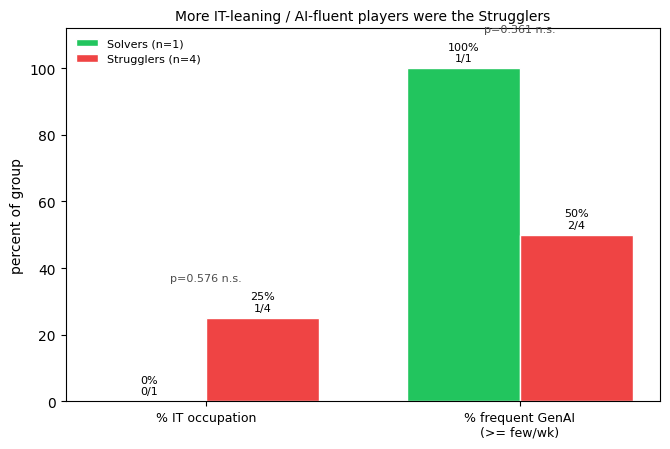

In [48]:
# --- Binary demographic splits: grouped single bars ---
# Same two comparisons the chi-square cell above tests (Solvers vs Strugglers), showing
# ONLY the informative category (% IT, % frequent GenAI user) so the takeaway reads fast.
# Reuses _won/_lost/FREQUENT_GENAI/_stats so bars and p-values match demo_won_lost_chi2.

METRICS = [
    ("% IT occupation", "occupation", lambda v: v == "it"),
    ("% frequent GenAI\n(>= few/wk)", "genai_usage", lambda v: v in FREQUENT_GENAI),
]
WON_C, LOST_C = "#22c55e", "#ef4444"

def _posfrac(rows, field, pred):
    """(pos_fraction, pos_n, total) over rows with a non-empty value."""
    vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
    pos = sum(1 for v in vals if pred(v)); tot = len(vals) or 1
    return pos / tot, pos, len(vals)

def _pstar(field, pred):
    def cnt(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        p = sum(1 for v in vals if pred(v)); return p, len(vals) - p
    wp, wn = cnt(_won); lp, ln = cnt(_lost)
    _, p, _, exp = _stats.chi2_contingency(np.array([[wp, wn], [lp, ln]]), correction=False)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    return p, star, exp.min()

fig, axb = plt.subplots(figsize=(6.8, 4.6))
x = np.arange(len(METRICS)); w = 0.36
for gi, (nm, rows, col) in enumerate([("Solvers", _won, WON_C), ("Strugglers", _lost, LOST_C)]):
    fr = [_posfrac(rows, f, p) for _, f, p in METRICS]
    xs = x + (gi - 0.5) * w
    axb.bar(xs, [100 * a[0] for a in fr], w, color=col, edgecolor="white",
            label=f"{nm} (n={fr[0][2]})")
    for xi, (frac, pn, tot) in zip(xs, fr):
        axb.text(xi, 100 * frac + 1.5, f"{100*frac:.0f}%\n{pn}/{tot}",
                 ha="center", va="bottom", fontsize=8)
# p-value sits just above the taller bar of each pair (clear of the legend)
for xi, (_, f, p) in zip(x, METRICS):
    pv, star, _ = _pstar(f, p)
    hmax = max(100 * _posfrac(_won, f, p)[0], 100 * _posfrac(_lost, f, p)[0])
    axb.text(xi, hmax + 11, f"p={pv:.3f} {star}", ha="center", fontsize=8, color="0.3")
axb.set_xticks(x); axb.set_xticklabels([m[0] for m in METRICS], fontsize=9)
axb.set_ylim(0, 112); axb.set_ylabel("percent of group")
axb.set_title("More IT-leaning / AI-fluent players were the Strugglers", fontsize=10)
axb.legend(fontsize=8, loc="upper left", frameon=False)       # left: clear of the right-hand p-value
plt.tight_layout(); plt.show()


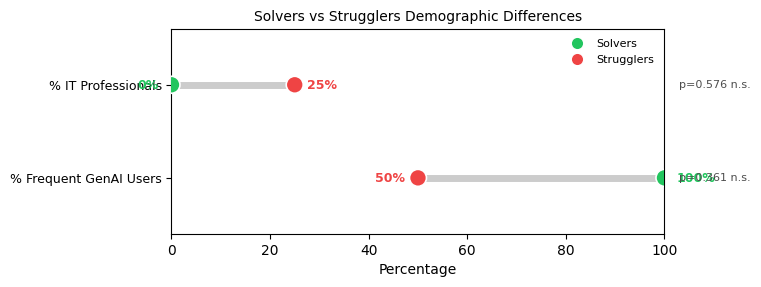

In [49]:
# --- Binary demographic splits: dumbbell (Solvers vs Strugglers gap) ---
# Same two comparisons as the chi-square / grouped-bar cells; one row per metric with a
# green Solvers-dot and red Strugglers-dot on a shared 0-100% axis, gap length = the effect.
# Group identity is in the legend; only the % value labels each dot (keeps text off the
# y-axis labels), and the chi-square p-value gets its own column in the right margin.
METRICS = [
    ("% IT Professionals", "occupation", lambda v: v == "it"),
    ("% Frequent GenAI Users", "genai_usage", lambda v: v in FREQUENT_GENAI),
]
WON_C, LOST_C = "#22c55e", "#ef4444"

def _posfrac(rows, field, pred):
    vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
    pos = sum(1 for v in vals if pred(v)); tot = len(vals) or 1
    return pos / tot, pos, len(vals)

def _pstar(field, pred):
    def cnt(rows):
        vals = [r.get(field) for r in rows if r.get(field) not in (None, "")]
        p = sum(1 for v in vals if pred(v)); return p, len(vals) - p
    wp, wn = cnt(_won); lp, ln = cnt(_lost)
    _, p, _, exp = _stats.chi2_contingency(np.array([[wp, wn], [lp, ln]]), correction=False)
    star = "***" if p < .001 else "**" if p < .01 else "*" if p < .05 else "n.s."
    return p, star, exp.min()

import matplotlib.transforms as mtransforms
fig, axd = plt.subplots(figsize=(8.5, 3.2))
y = np.arange(len(METRICS))[::-1]                     # first metric on top
p_trans = mtransforms.blended_transform_factory(axd.transAxes, axd.transData)  # x=axes, y=data
for yi, (label, f, p) in zip(y, METRICS):
    wf, lf = 100 * _posfrac(_won, f, p)[0], 100 * _posfrac(_lost, f, p)[0]
    axd.plot([wf, lf], [yi, yi], color="0.8", lw=5, zorder=1, solid_capstyle="round")
    axd.scatter([wf, lf], [yi, yi], s=150, color=[WON_C, LOST_C], zorder=3,
                edgecolor="white", lw=1.2)
    # short % label on the OUTER side of each dot (smaller -> left, larger -> right)
    lo, hi = (wf, WON_C), (lf, LOST_C)
    if wf > lf: lo, hi = hi, lo
    axd.annotate(f"{lo[0]:.0f}%", (lo[0], yi), xytext=(-9, 0), textcoords="offset points",
                 ha="right", va="center", fontsize=9, color=lo[1], fontweight="bold")
    axd.annotate(f"{hi[0]:.0f}%", (hi[0], yi), xytext=(9, 0), textcoords="offset points",
                 ha="left", va="center", fontsize=9, color=hi[1], fontweight="bold")
    pv, star, _ = _pstar(f, p)
    axd.text(1.03, yi, f"p={pv:.3f} {star}", transform=p_trans, va="center",
             ha="left", fontsize=8, color="0.3", clip_on=False)
axd.set_yticks(y); axd.set_yticklabels([m[0] for m in METRICS], fontsize=9)
axd.set_xlim(0, 100); axd.set_ylim(-0.6, len(METRICS) - 0.4)
axd.set_xlabel("Percentage")
axd.set_title("Solvers vs Strugglers Demographic Differences", fontsize=10)
handles = [plt.Line2D([0], [0], marker="o", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers", WON_C), ("Strugglers", LOST_C)]]
axd.legend(handles=handles, loc="upper right", ncol=1, frameon=False, fontsize=8)  # empty corner
fig.subplots_adjust(left=0.24, right=0.82, top=0.84, bottom=0.20)   # room for y-labels + p-column
plt.show()


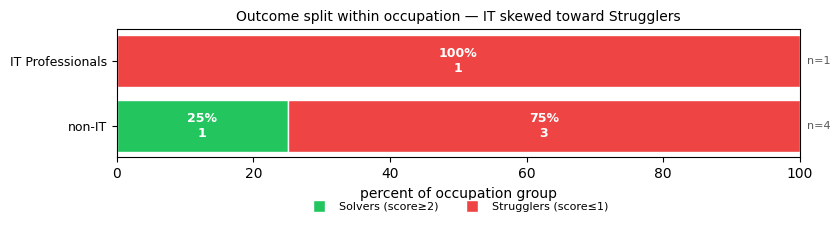

In [50]:
# --- Within-occupation outcome split: horizontal stacked bars ---
# Flips the conditioning of the charts above: instead of "% of Solvers who are IT",
# this asks "of IT professionals, what share were Solvers vs Strugglers?" Each row is a
# 100%-stacked bar (Solvers=green, Strugglers=red). non-IT row added for contrast.
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

ROWS = [
    ("IT Professionals", lambda d: d.get("occupation") == "it"),
    ("non-IT",           lambda d: d.get("occupation") not in (None, "", "it")),
]

fig, axo = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this occupation
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this occupation
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axo.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axo.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axo.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axo.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axo.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axo.set_yticks(y); axo.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axo.set_xlim(0, 100); axo.set_xlabel("percent of occupation group")
axo.set_title("Outcome split within occupation \u2014 IT skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axo.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


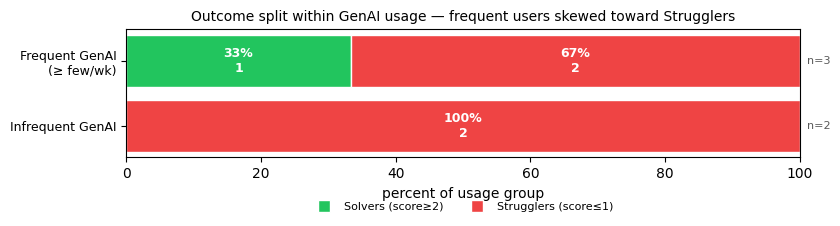

In [51]:
# --- Within-GenAI-usage outcome split: horizontal stacked bars ---
# Same flip as the occupation cell, but by AI fluency: "of frequent GenAI users, what
# share were Solvers vs Strugglers?" Frequent = few_times_week/daily/several_times_day
# (weekly counts as infrequent, matching FREQUENT_GENAI above). Rows 100%-stacked.
try:
    FREQUENT_GENAI
except NameError:
    FREQUENT_GENAI = {"few_times_week", "daily", "several_times_day"}
def _demo(pids):
    return [json.load(open(RECORDINGS_BASE / pid / "demographics.json"))
            for pid in pids if (RECORDINGS_BASE / pid / "demographics.json").exists()]
_won, _lost = _demo(good_pid), _demo(bad_pid)
WON_C, LOST_C = "#22c55e", "#ef4444"

def _gv(d):
    v = d.get("genai_usage"); return None if v in (None, "") else v
ROWS = [
    ("Frequent GenAI\n(\u2265 few/wk)", lambda d: _gv(d) in FREQUENT_GENAI),
    ("Infrequent GenAI",              lambda d: _gv(d) is not None and _gv(d) not in FREQUENT_GENAI),
]

fig, axg = plt.subplots(figsize=(8.5, 2.8))
y = np.arange(len(ROWS))[::-1]                      # first row on top
for yi, (label, pred) in zip(y, ROWS):
    s = sum(1 for d in _won  if pred(d))            # Solvers in this usage band
    t = sum(1 for d in _lost if pred(d))            # Strugglers in this usage band
    tot = s + t or 1
    sp, tp = 100 * s / tot, 100 * t / tot
    axg.barh(yi, sp,        color=WON_C,  edgecolor="white")
    axg.barh(yi, tp, left=sp, color=LOST_C, edgecolor="white")
    if sp > 8:
        axg.text(sp / 2, yi, f"{sp:.0f}%\n{s}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    if tp > 8:
        axg.text(sp + tp / 2, yi, f"{tp:.0f}%\n{t}", ha="center", va="center",
                 color="white", fontsize=9, fontweight="bold")
    axg.text(101, yi, f"n={tot}", va="center", ha="left", fontsize=8, color="0.35")

axg.set_yticks(y); axg.set_yticklabels([r[0] for r in ROWS], fontsize=9)
axg.set_xlim(0, 100); axg.set_xlabel("percent of usage group")
axg.set_title("Outcome split within GenAI usage \u2014 frequent users skewed toward Strugglers", fontsize=10)
handles = [plt.Line2D([0], [0], marker="s", ls="", ms=9, mfc=c, mec="white", label=nm)
           for nm, c in [("Solvers (score\u22652)", WON_C), ("Strugglers (score\u22641)", LOST_C)]]
axg.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.5),
           ncol=2, frameon=False, fontsize=8)
plt.tight_layout(); plt.show()
